In [1]:
# Mount Google Drive REMEMBER leave the runtime as Python 3 while running this cell
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Load the data
# Replace with your actual path and dataset
file_path <- "/content/drive/My Drive/Penguin_size/penguins_size.csv"

# Read the dataset
data <- read.csv(file_path)

# Check the data
head(data)

# dimensions of the dataset (rows x cols)
dim(data)

# Check data types of variables
sapply(data, class)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<chr>
1,Adelie,Torgersen,39.1,18.7,181,3750,MALE
2,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
3,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
4,Adelie,Torgersen,NA,NA,NA,NA,NA
5,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
6,Adelie,Torgersen,39.3,20.6,190,3650,MALE


[1] 344   7

species            island  culmen_length_mm   culmen_depth_mm 
      "character"       "character"         "numeric"         "numeric" 
flipper_length_mm       body_mass_g               sex 
        "integer"         "integer"       "character"

In [2]:
# Structure & Summary
# View the structure and summary of the data

cat("=== Structure of Dataset ===\n")
str(data)

cat("\n=== Summary Statistics ===\n")
summary(data)

=== Structure of Dataset ===
'data.frame':	344 obs. of  7 variables:
 $ species          : chr  "Adelie" "Adelie" "Adelie" "Adelie" ...
 $ island           : chr  "Torgersen" "Torgersen" "Torgersen" "Torgersen" ...
 $ culmen_length_mm : num  39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ culmen_depth_mm  : num  18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipper_length_mm: int  181 186 195 NA 193 190 181 195 193 190 ...
 $ body_mass_g      : int  3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex              : chr  "MALE" "FEMALE" "FEMALE" NA ...

=== Summary Statistics ===


   species             island          culmen_length_mm culmen_depth_mm
 Length:344         Length:344         Min.   :32.10    Min.   :13.10  
 Class :character   Class :character   1st Qu.:39.23    1st Qu.:15.60  
 Mode  :character   Mode  :character   Median :44.45    Median :17.30  
                                       Mean   :43.92    Mean   :17.15  
                                       3rd Qu.:48.50    3rd Qu.:18.70  
                                       Max.   :59.60    Max.   :21.50  
                                       NA's   :2        NA's   :2      
 flipper_length_mm  body_mass_g       sex           
 Min.   :172.0     Min.   :2700   Length:344        
 1st Qu.:190.0     1st Qu.:3550   Class :character  
 Median :197.0     Median :4050   Mode  :character  
 Mean   :200.9     Mean   :4202                     
 3rd Qu.:213.0     3rd Qu.:4750                     
 Max.   :231.0     Max.   :6300                     
 NA's   :2         NA's   :2                        

In [3]:
# convert the character attribute(s) to factor (for working with categorical variables in R)
# note this code segment was used for the Iris dataset - adapt according to the dataset and variables
data$species <- as.factor(data$species)
data$island <- as.factor(data$island)
data$sex <- as.factor(data$sex)

names(data)[names(data) == "culmen_length_mm"] <- "culmenlength"
names(data)[names(data) == "culmen_depth_mm"] <- "culmendepth"
names(data)[names(data) == "flipper_length_mm"] <- "flipperlength"
names(data)[names(data) == "body_mass_g"] <- "bodymass"

str(data)

'data.frame':	344 obs. of  7 variables:
 $ species      : Factor w/ 3 levels "Adelie","Chinstrap",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ island       : Factor w/ 3 levels "Biscoe","Dream",..: 3 3 3 3 3 3 3 3 3 3 ...
 $ culmenlength : num  39.1 39.5 40.3 NA 36.7 39.3 38.9 39.2 34.1 42 ...
 $ culmendepth  : num  18.7 17.4 18 NA 19.3 20.6 17.8 19.6 18.1 20.2 ...
 $ flipperlength: int  181 186 195 NA 193 190 181 195 193 190 ...
 $ bodymass     : int  3750 3800 3250 NA 3450 3650 3625 4675 3475 4250 ...
 $ sex          : Factor w/ 3 levels ".","FEMALE","MALE": 3 2 2 NA 2 3 2 3 NA NA ...


In [4]:
# Assess the quality of the dataset

# Check for missing values
# Count the missing values in each column
colSums(is.na(data))

species        island  culmenlength   culmendepth flipperlength 
            0             0             2             2             2 
     bodymass           sex 
            2            10

In [5]:
# display the rows with missing values for an attribute
cat("\n=== missing values culmenlength ===\n")
data[!complete.cases(data$culmenlength), ]

cat("\n=== missing values culmendepth ===\n")
data[!complete.cases(data$culmendepth), ]

cat("\n=== missing values flipperlength ===\n")
data[!complete.cases(data$flipperlength), ]

cat("\n=== missing values bodymass ===\n")
data[!complete.cases(data$bodymass), ]

cat("\n=== missing values sex ===\n")
data[!complete.cases(data$sex), ]


=== missing values culmenlength ===


,species,island,culmenlength,culmendepth,flipperlength,bodymass,sex
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
4,Adelie,Torgersen,NA,NA,NA,NA,NA
340,Gentoo,Biscoe,NA,NA,NA,NA,NA



=== missing values culmendepth ===


,species,island,culmenlength,culmendepth,flipperlength,bodymass,sex
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
4,Adelie,Torgersen,NA,NA,NA,NA,NA
340,Gentoo,Biscoe,NA,NA,NA,NA,NA



=== missing values flipperlength ===


,species,island,culmenlength,culmendepth,flipperlength,bodymass,sex
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
4,Adelie,Torgersen,NA,NA,NA,NA,NA
340,Gentoo,Biscoe,NA,NA,NA,NA,NA



=== missing values bodymass ===


,species,island,culmenlength,culmendepth,flipperlength,bodymass,sex
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
4,Adelie,Torgersen,NA,NA,NA,NA,NA
340,Gentoo,Biscoe,NA,NA,NA,NA,NA



=== missing values sex ===


,species,island,culmenlength,culmendepth,flipperlength,bodymass,sex
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>
4,Adelie,Torgersen,NA,NA,NA,NA,NA
9,Adelie,Torgersen,34.1,18.1,193,3475,NA
10,Adelie,Torgersen,42.0,20.2,190,4250,NA
11,Adelie,Torgersen,37.8,17.1,186,3300,NA
12,Adelie,Torgersen,37.8,17.3,180,3700,NA
48,Adelie,Dream,37.5,18.9,179,2975,NA
247,Gentoo,Biscoe,44.5,14.3,216,4100,NA
287,Gentoo,Biscoe,46.2,14.4,214,4650,NA
325,Gentoo,Biscoe,47.3,13.8,216,4725,NA


In [6]:
# remove rows with missing values - 10 rows in total (save as a new data frame)
data_new <- na.omit(data)

# check the dimension of the data after removing rows
dim(data_new)

[1] 334   7

In [7]:
# Check for duplicate data
# Count the duplicate data
sum(duplicated(data_new))

# Show the rows with duplicate data
data_new[duplicated(data_new), ]

# Drops any duplicates (if required)
data_unique <- data_new[!duplicated(data_new), ]

cat("Rows before:", nrow(data_new), "\nRows after:", nrow(data_unique))

[1] 0

species,island,culmenlength,culmendepth,flipperlength,bodymass,sex
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>


Rows before: 334 
Rows after: 334

In [8]:
# Basic statistics UNIVARIATE Analysis
numeric_data <- sapply(data_new, is.numeric)
# Using the numeric data create a table of the sumarry statistics for mean, median, standard deviation and interquatile range
stats <- data.frame(
  Variable = names(data_new)[numeric_data],
  Mean = sapply(data_new[, numeric_data], mean),
  Median = sapply(data_new[, numeric_data], median),
  SD = sapply(data_new[, numeric_data], sd),
  interquartile = sapply(data_new[, numeric_data], IQR) )
  stats

,Variable,Mean,Median,SD,interquartile
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
culmenlength,culmenlength,43.99431,44.5,5.460521,9.075
culmendepth,culmendepth,17.16048,17.3,1.967909,3.100
flipperlength,flipperlength,201.01497,197.0,14.022175,23.000
bodymass,bodymass,4209.05689,4050.0,804.836129,1243.750


# **UNIVARIATE Analysis**

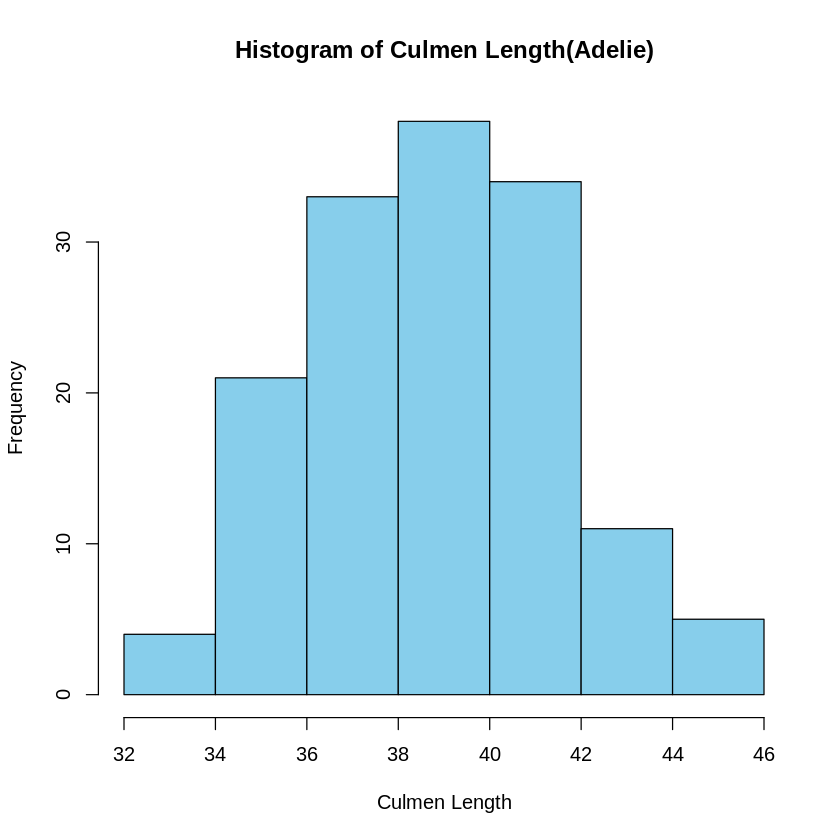

In [10]:
#Histogram of Culmen Length for Adelie species

hist(x = data_new$culmenlength[data_new$species == "Adelie"],
     main = "Histogram of Culmen Length(Adelie)",
     xlab = "Culmen Length",
     col = "skyblue",
     border = "black")

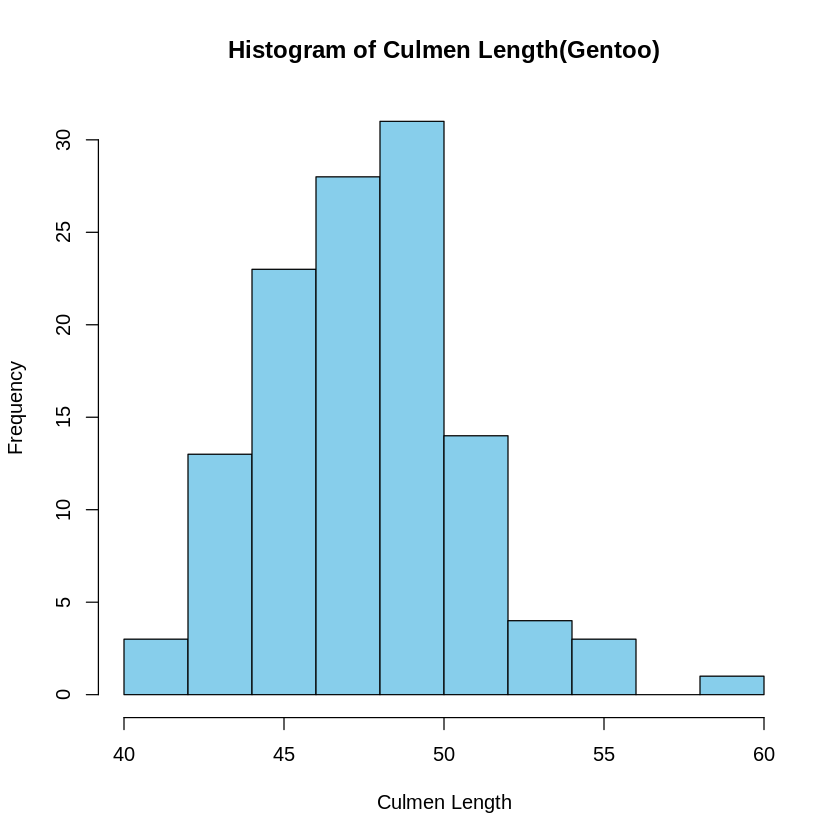

In [11]:
#Histogram of Culmen Length for Gentoo species

hist(x = data_new$culmenlength[data_new$species == "Gentoo"],
     main = "Histogram of Culmen Length(Gentoo)",
     xlab = "Culmen Length",
     col = "skyblue",
     border = "black")

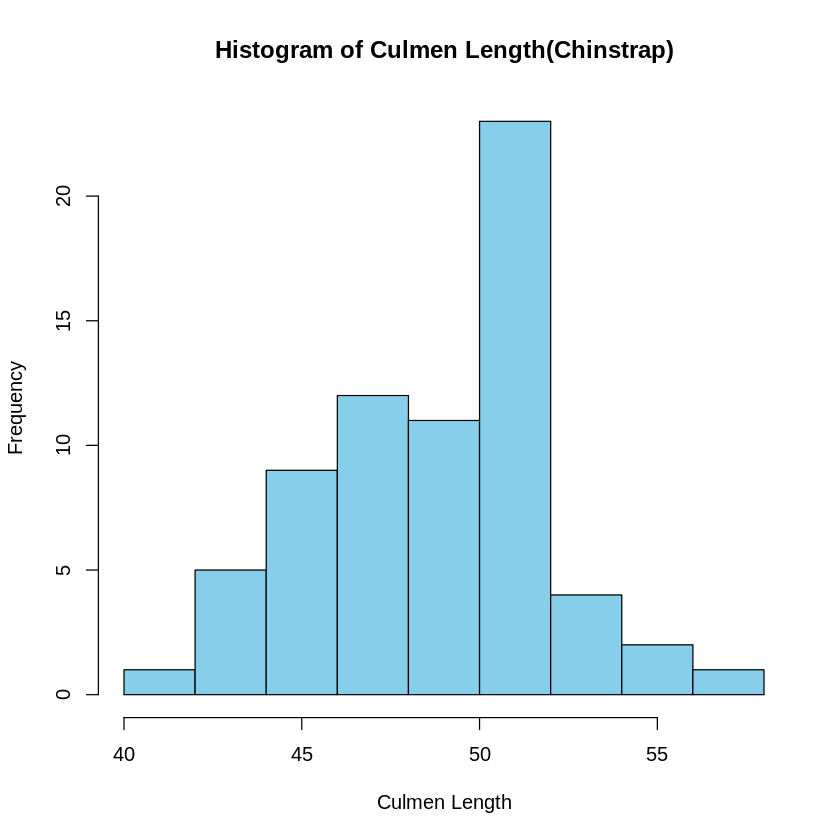

In [12]:
#Histogram of Culmen Length for Chinstrap species

hist(x = data_new$culmenlength[data_new$species == "Chinstrap"],
     main = "Histogram of Culmen Length(Chinstrap)",
     xlab = "Culmen Length",
     col = "skyblue",
     border = "black")

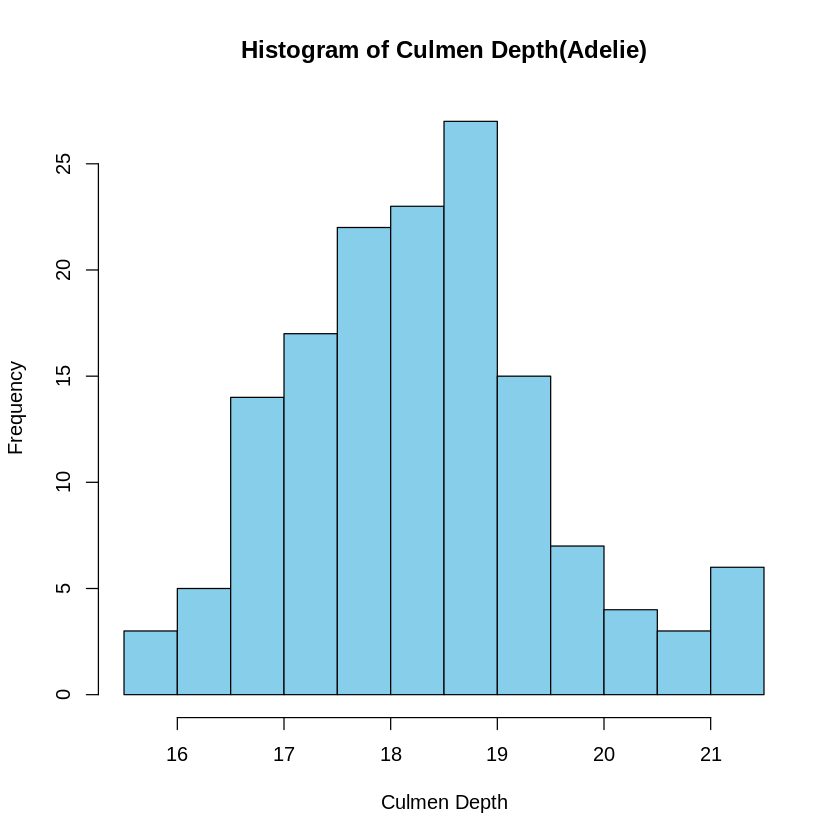

In [13]:
#Histogram of Culmen Depth for Adelie species

hist(x = data_new$culmendepth[data_new$species == "Adelie"],
     main = "Histogram of Culmen Depth(Adelie)",
     xlab = "Culmen Depth",
     col = "skyblue",
     border = "black")

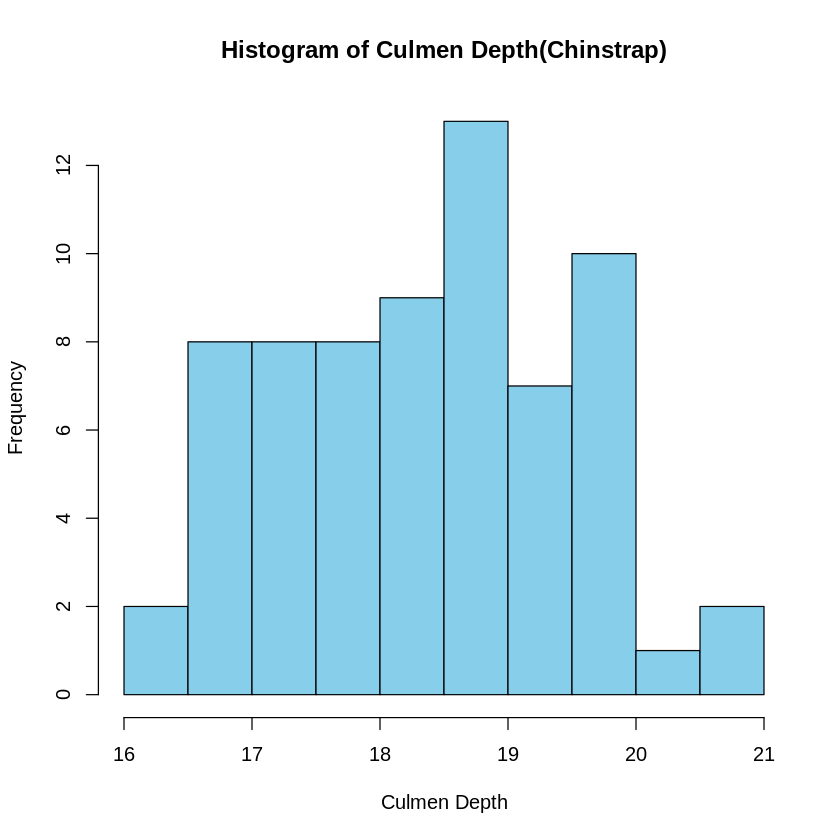

In [14]:
#Histogram of Culmen Depth for Chinstrap species

hist(x = data_new$culmendepth[data_new$species == "Chinstrap"],
     main = "Histogram of Culmen Depth(Chinstrap)",
     xlab = "Culmen Depth",
     col = "skyblue",
     border = "black")

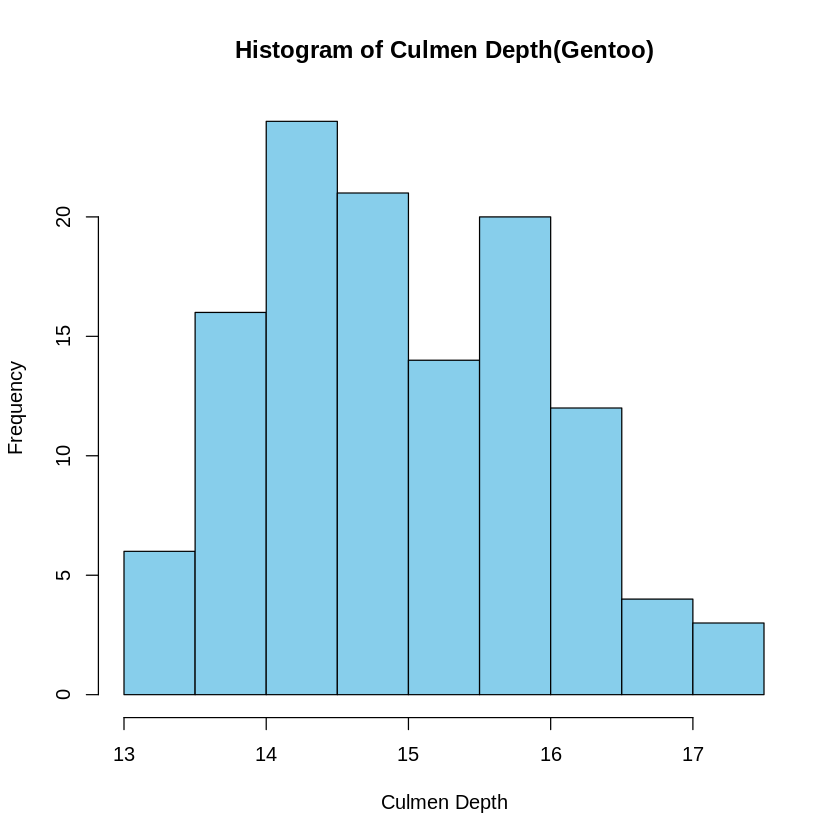

In [15]:
#Histogram of Culmen Depth for Gentoo species

hist(x = data_new$culmendepth[data_new$species == "Gentoo"],
     main = "Histogram of Culmen Depth(Gentoo)",
     xlab = "Culmen Depth",
     col = "skyblue",
     border = "black")

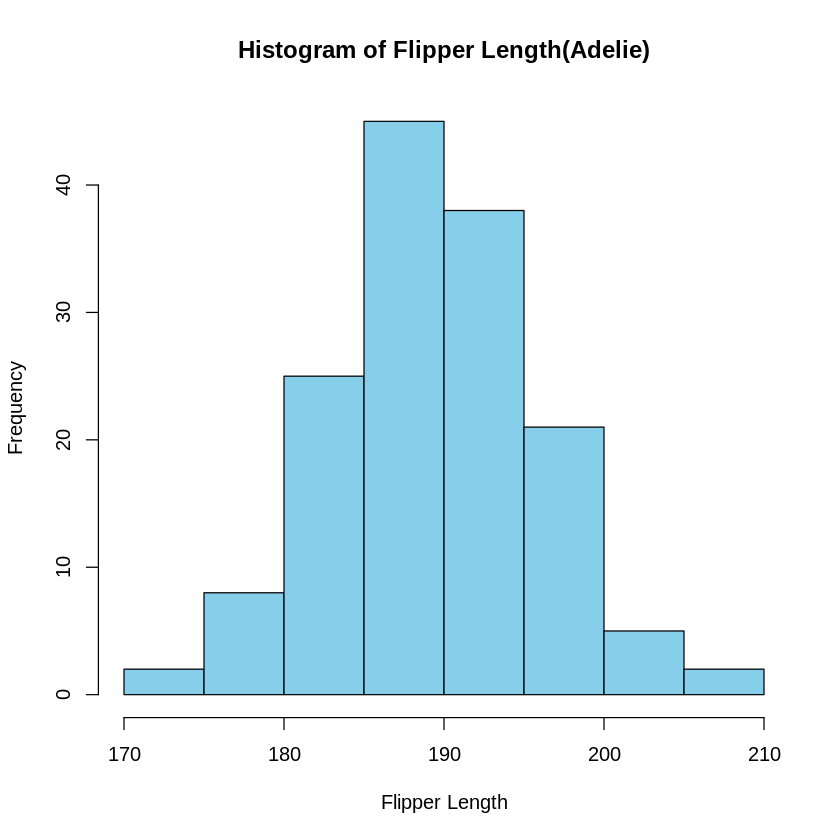

In [16]:
#Histogram of Flipper Length for Adelie species

hist(x = data_new$flipperlength[data_new$species == "Adelie"],
     main = "Histogram of Flipper Length(Adelie)",
     xlab = "Flipper Length",
     col = "skyblue",
     border = "black")

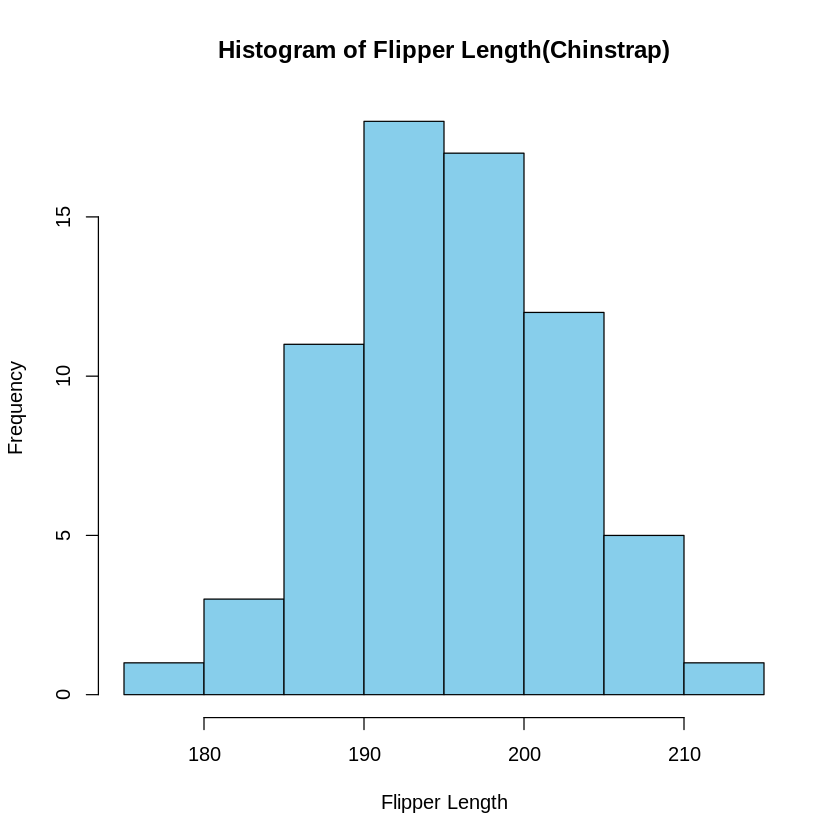

In [17]:
#Histogram of Flipper Length for Chinstrap species

hist(x = data_new$flipperlength[data_new$species == "Chinstrap"],
     main = "Histogram of Flipper Length(Chinstrap)",
     xlab = "Flipper Length",
     col = "skyblue",
     border = "black")

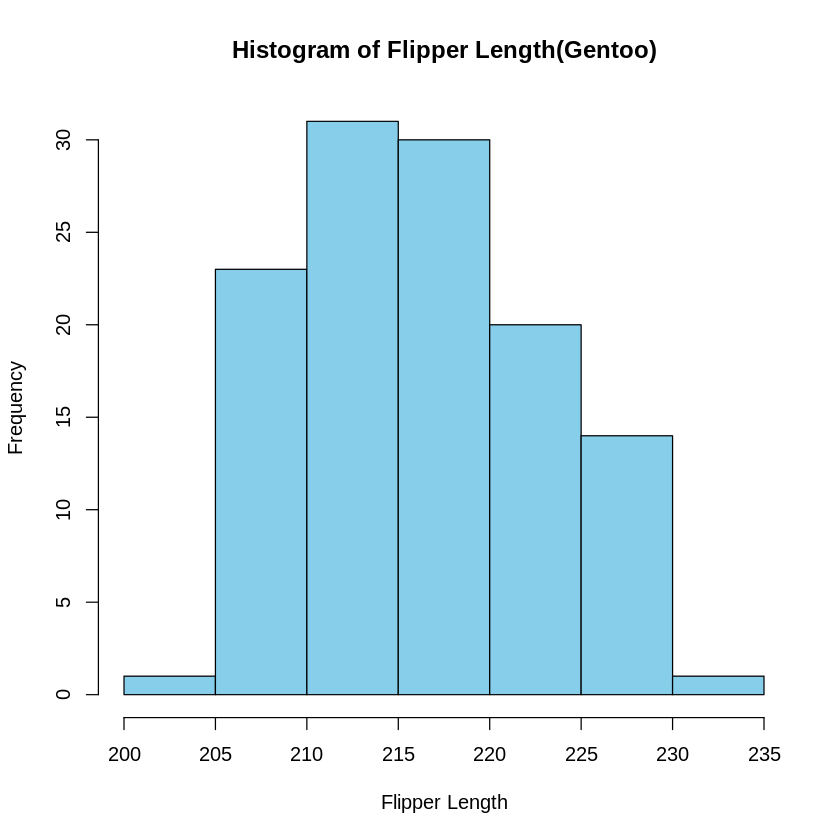

In [18]:
#Histogram of Flipper Length for Gentoo species

hist(x = data_new$flipperlength[data_new$species == "Gentoo"],
     main = "Histogram of Flipper Length(Gentoo)",
     xlab = "Flipper Length",
     col = "skyblue",
     border = "black")

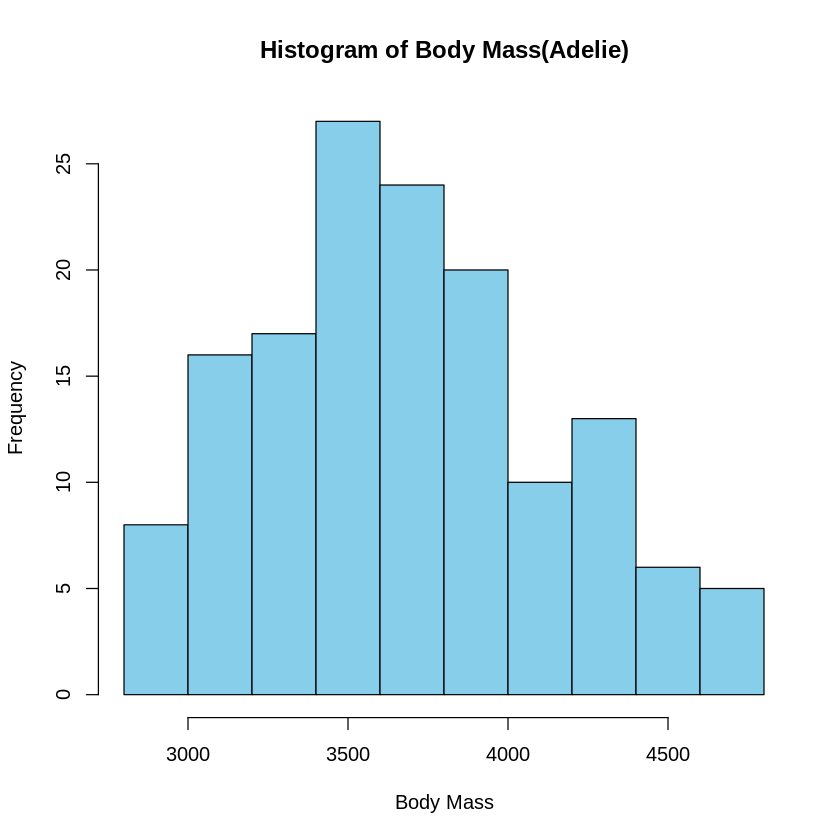

In [19]:
#Histogram of Body Mass for Adelie species

hist(x = data_new$bodymass[data_new$species == "Adelie"],
     main = "Histogram of Body Mass(Adelie)",
     xlab = "Body Mass",
     col = "skyblue",
     border = "black")

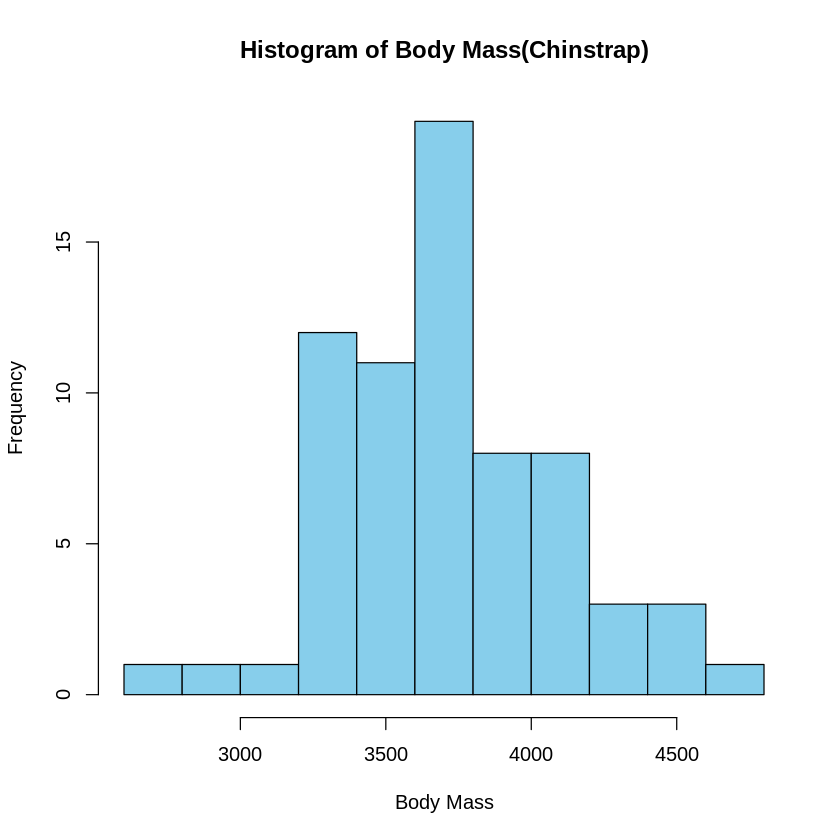

In [20]:
#Histogram of Body Mass for Chinstrap species

hist(x = data_new$bodymass[data_new$species == "Chinstrap"],
     main = "Histogram of Body Mass(Chinstrap)",
     xlab = "Body Mass",
     col = "skyblue",
     border = "black")

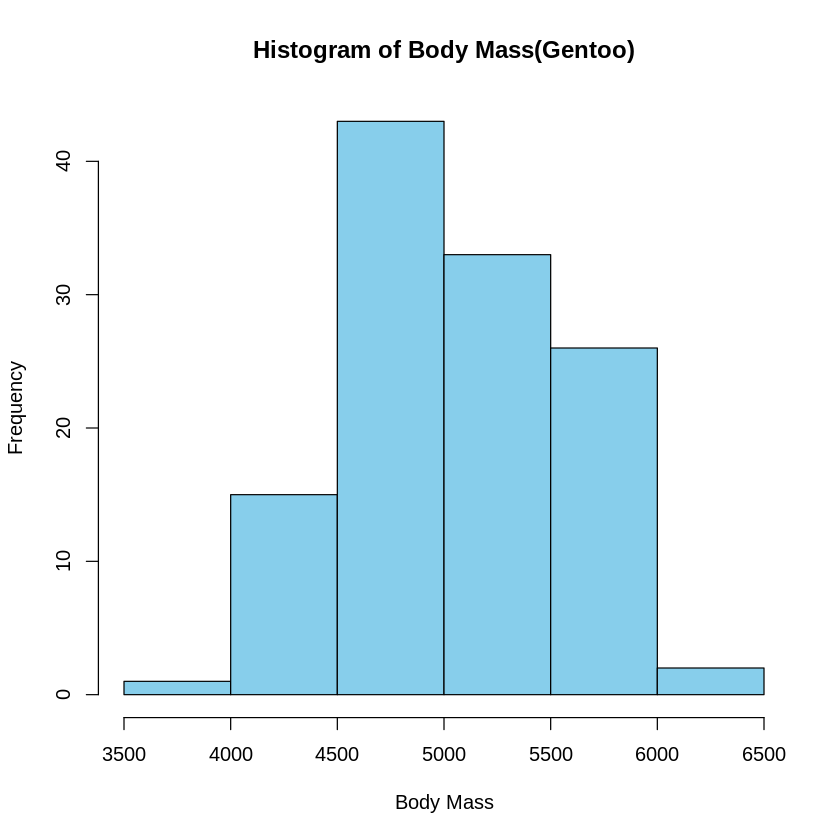

In [21]:
#Histogram of Body Mass for Gentoo species

hist(x = data_new$bodymass[data_new$species == "Gentoo"],
     main = "Histogram of Body Mass(Gentoo)",
     xlab = "Body Mass",
     col = "skyblue",
     border = "black")

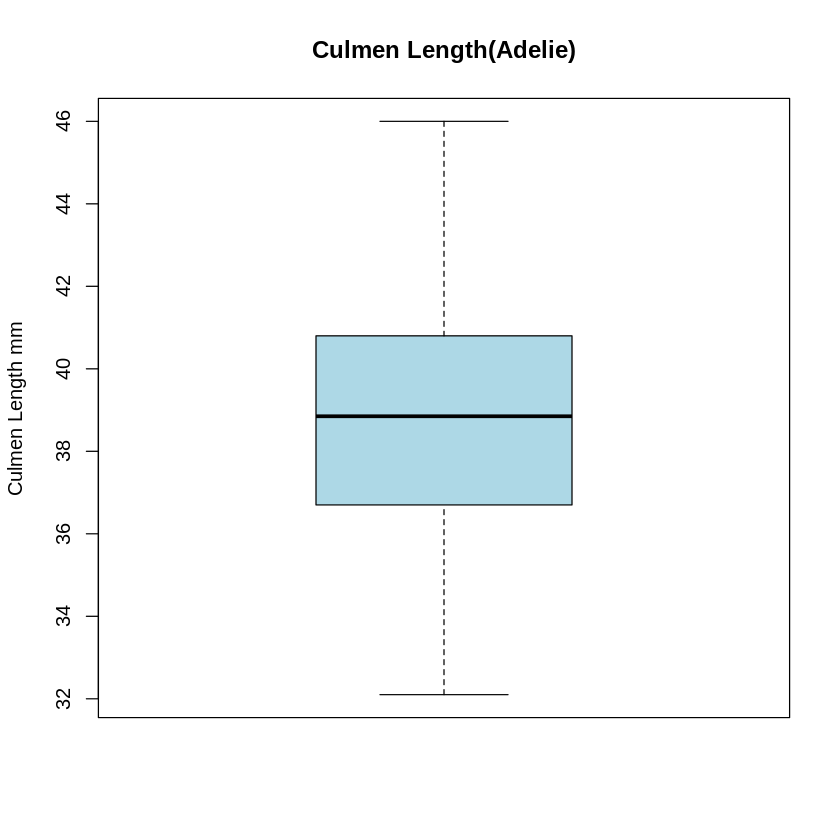

In [22]:

# Boxplot - Culmen Length for Adelie species
boxplot(x = data_new$culmenlength[data_new$species == "Adelie"],
        main = "Culmen Length(Adelie)",
        ylab = "Culmen Length mm",
        col = "lightblue")


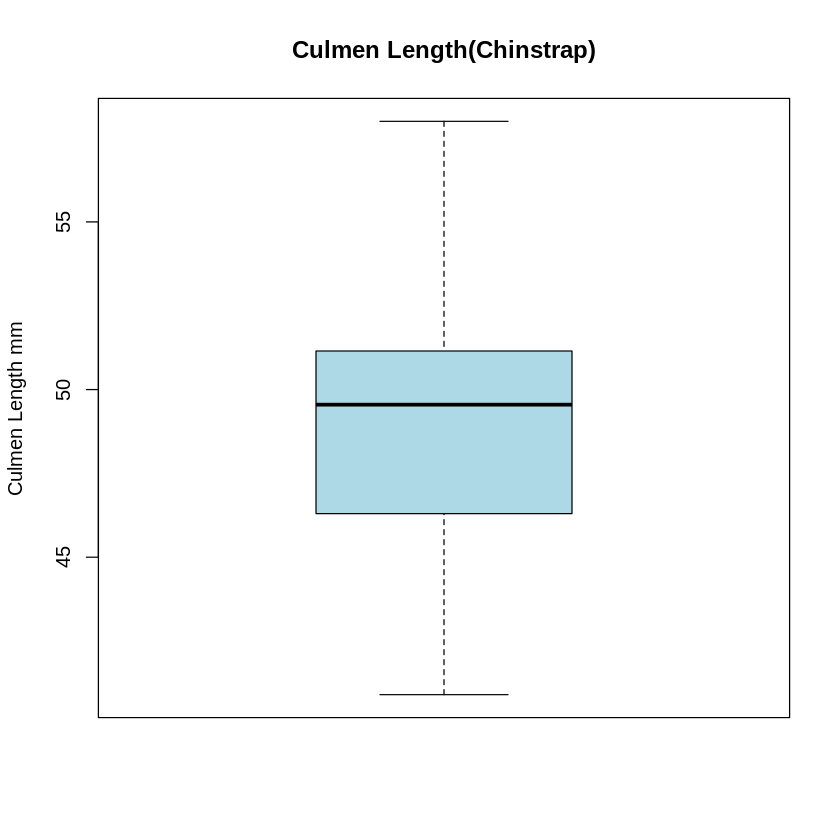

In [23]:

# Boxplot - Culmen Length for Chinstrap species
boxplot(x = data_new$culmenlength[data_new$species == "Chinstrap"],
        main = "Culmen Length(Chinstrap)",
        ylab = "Culmen Length mm",
        col = "lightblue")


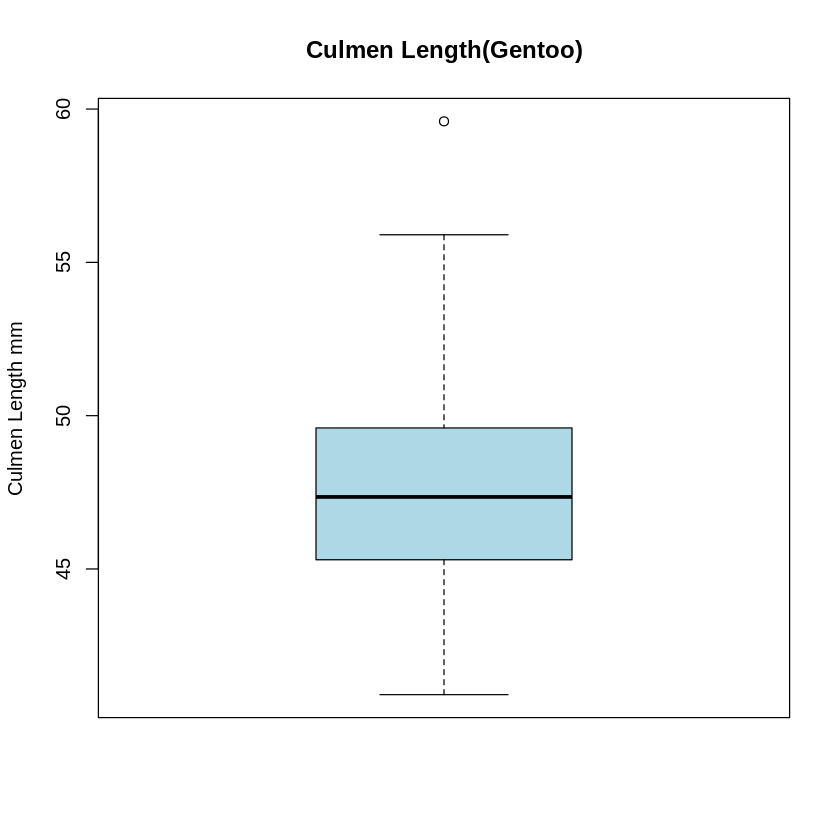

In [24]:

# Boxplot - Culmen Length for Gentoo species
boxplot(x = data_new$culmenlength[data_new$species == "Gentoo"],
        main = "Culmen Length(Gentoo)",
        ylab = "Culmen Length mm",
        col = "lightblue")


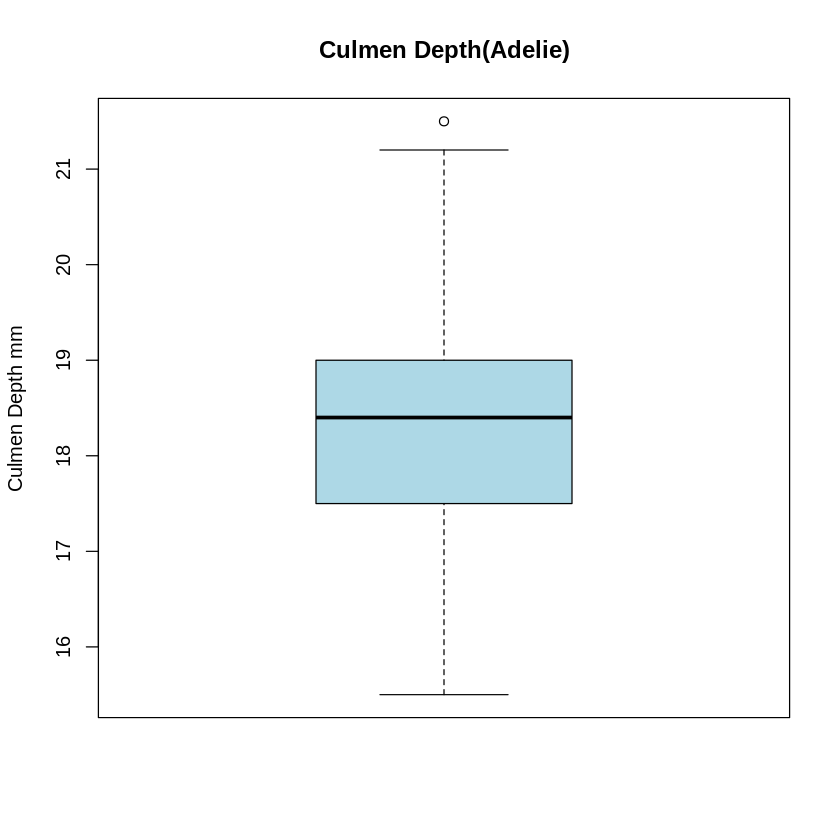

In [25]:

# Boxplot - Culmen Depth for Adelie species
boxplot(x = data_new$culmendepth[data_new$species == "Adelie"],
        main = "Culmen Depth(Adelie)",
        ylab = "Culmen Depth mm",
        col = "lightblue")


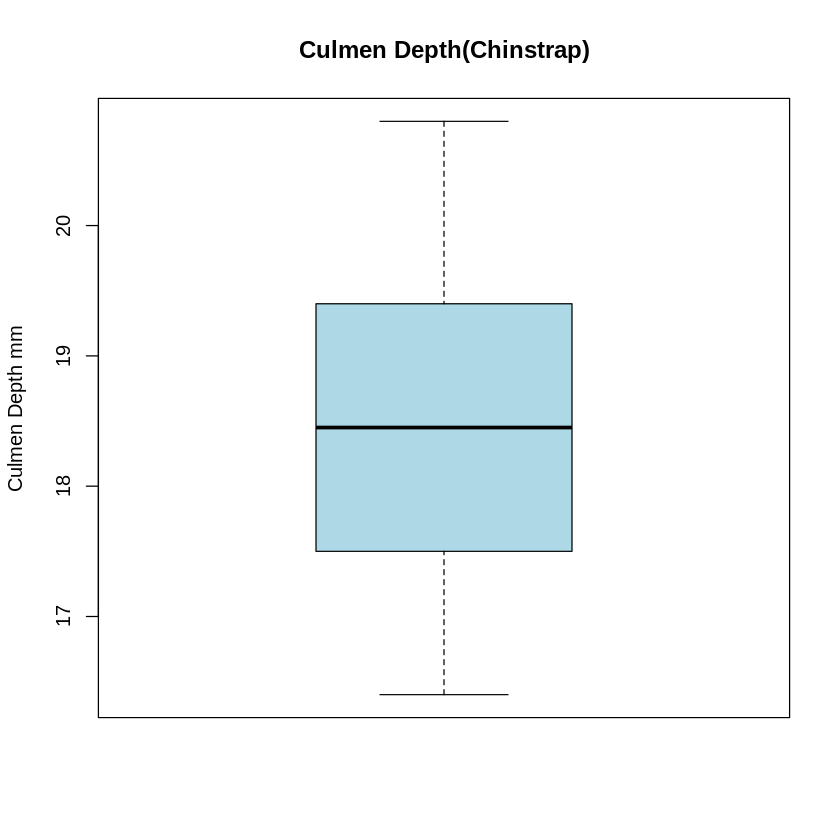

In [26]:

# Boxplot - Culmen Depth for Chinstrap species
boxplot(x = data_new$culmendepth[data_new$species == "Chinstrap"],
        main = "Culmen Depth(Chinstrap)",
        ylab = "Culmen Depth mm",
        col = "lightblue")


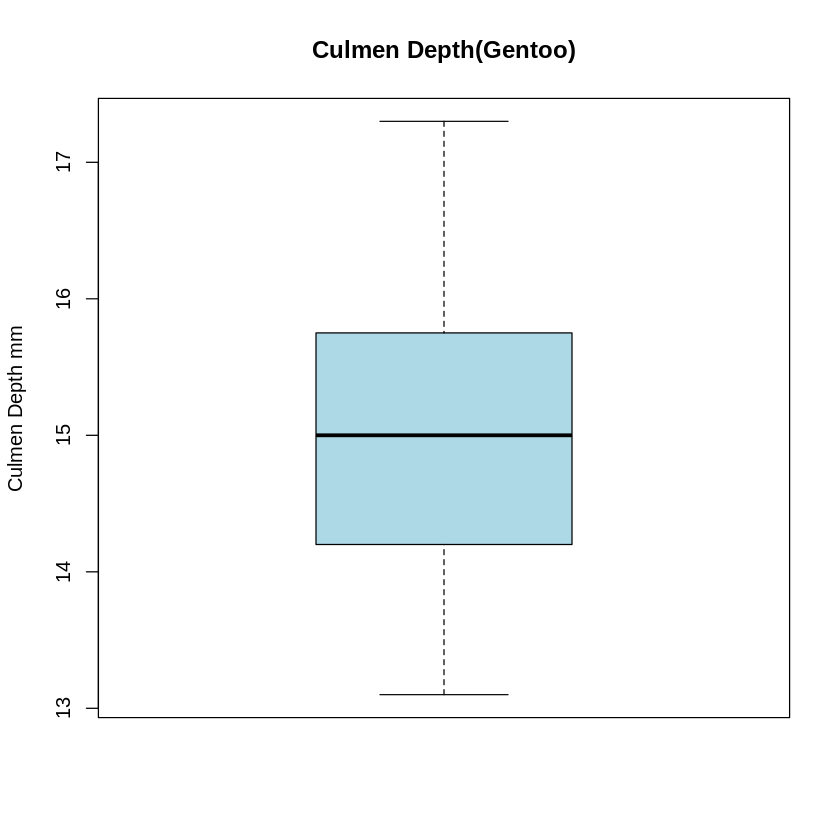

In [27]:

# Boxplot - Culmen Depth for Gentoo species
boxplot(x = data_new$culmendepth[data_new$species == "Gentoo"],
        main = "Culmen Depth(Gentoo)",
        ylab = "Culmen Depth mm",
        col = "lightblue")


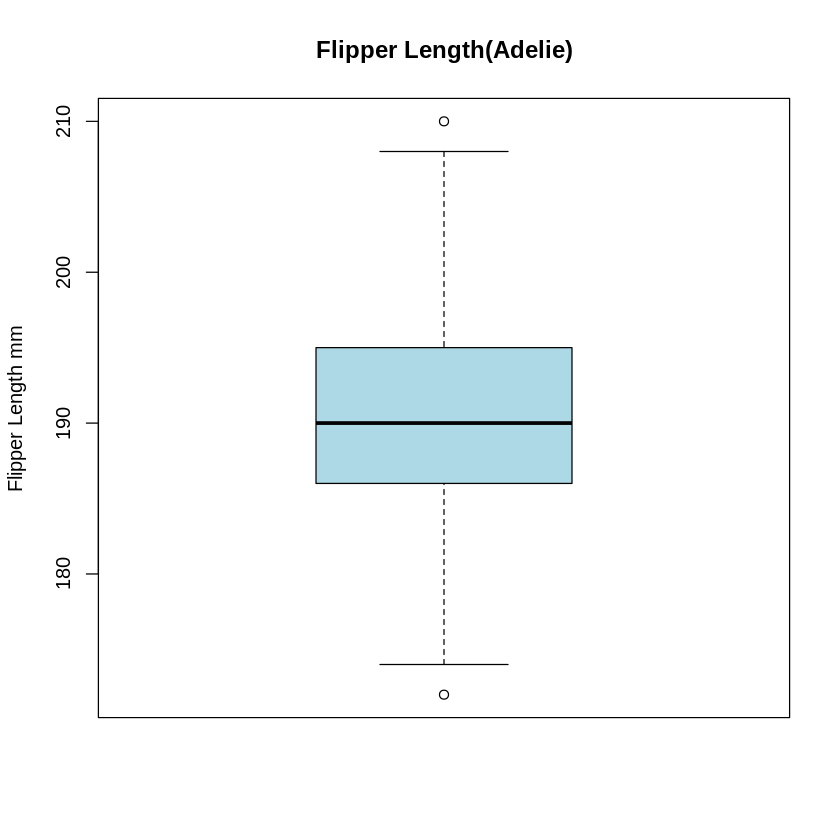

In [28]:

# Boxplot - Flipper Length for Adelie species
boxplot(x = data_new$flipperlength[data_new$species == "Adelie"],
        main = "Flipper Length(Adelie)",
        ylab = "Flipper Length mm",
        col = "lightblue")


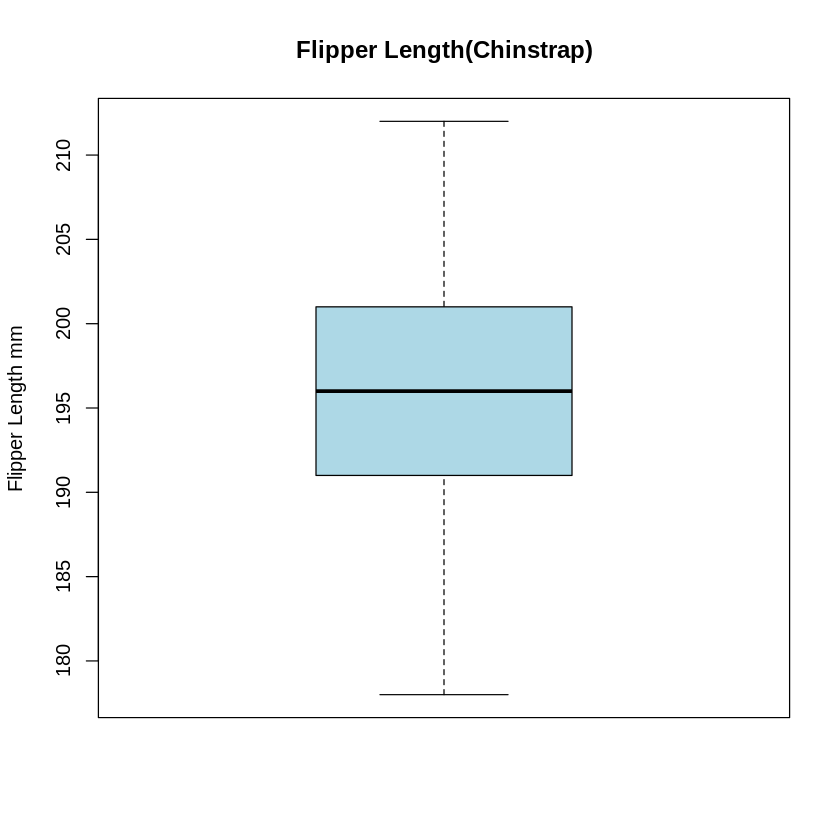

In [29]:

# Boxplot - Flipper Length for Chinstrap species
boxplot(x = data_new$flipperlength[data_new$species == "Chinstrap"],
        main = "Flipper Length(Chinstrap)",
        ylab = "Flipper Length mm",
        col = "lightblue")


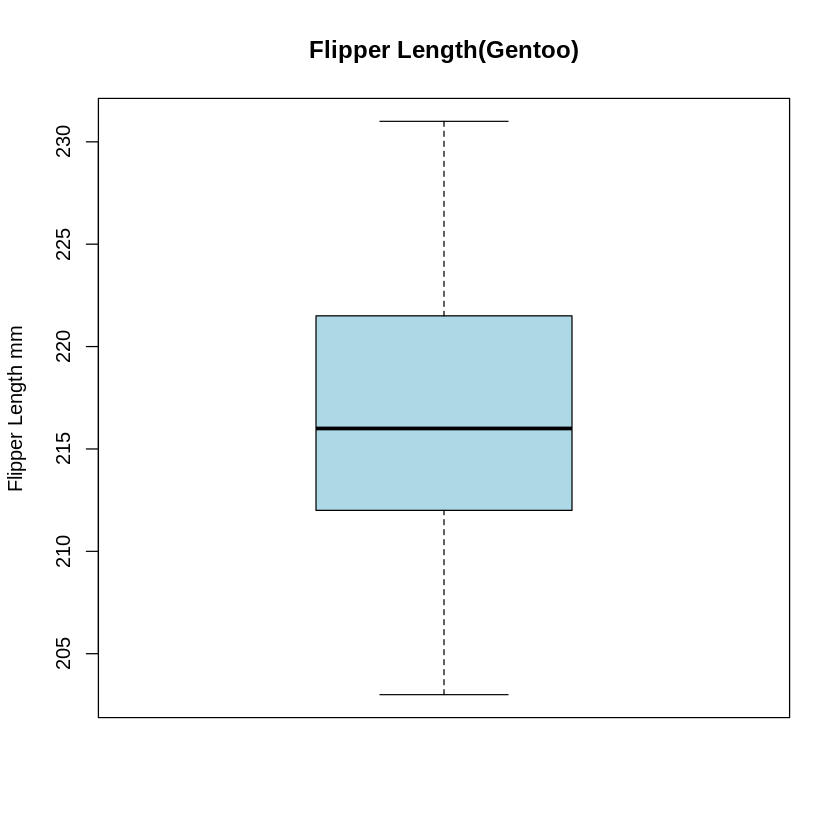

In [30]:

# Boxplot - Flipper Length for Gentoo species
boxplot(x = data_new$flipperlength[data_new$species == "Gentoo"],
        main = "Flipper Length(Gentoo)",
        ylab = "Flipper Length mm",
        col = "lightblue")


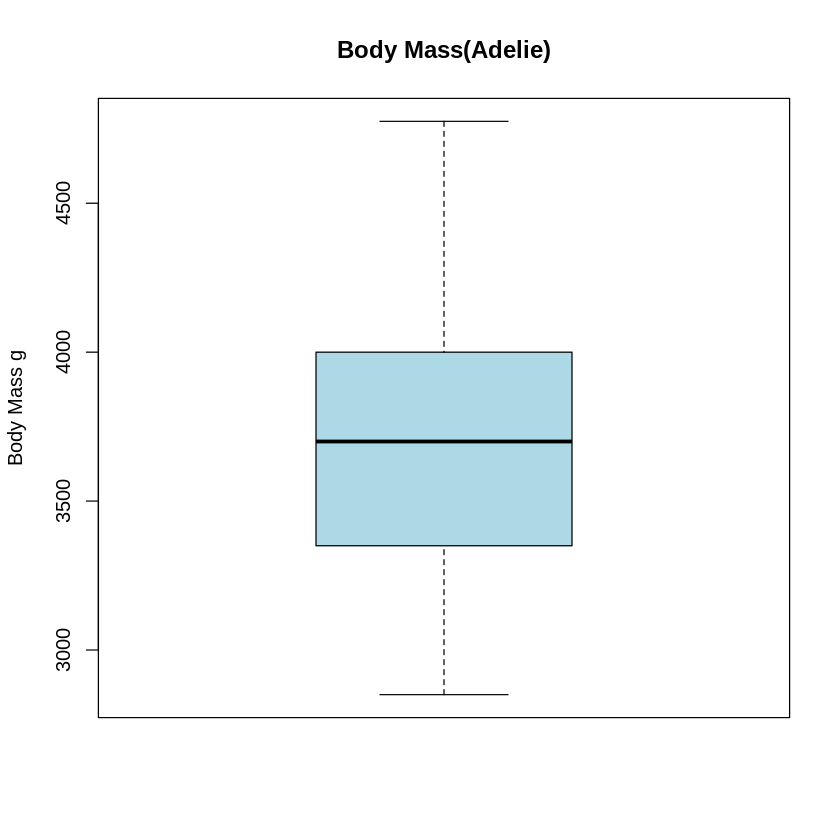

In [31]:

# Boxplot - Body Mass for Adelie species
boxplot(x = data_new$bodymass[data_new$species == "Adelie"],
        main = "Body Mass(Adelie)",
        ylab = "Body Mass g",
        col = "lightblue")


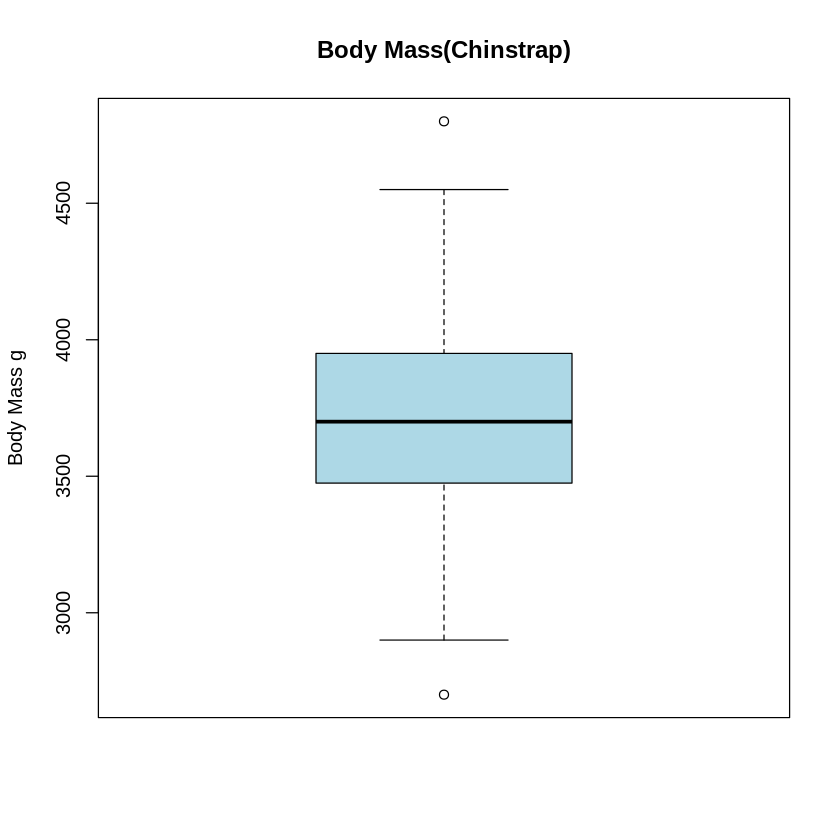

In [32]:

# Boxplot - Body Mass for Chinstrap species
boxplot(x = data_new$bodymass[data_new$species == "Chinstrap"],
        main = "Body Mass(Chinstrap)",
        ylab = "Body Mass g",
        col = "lightblue")


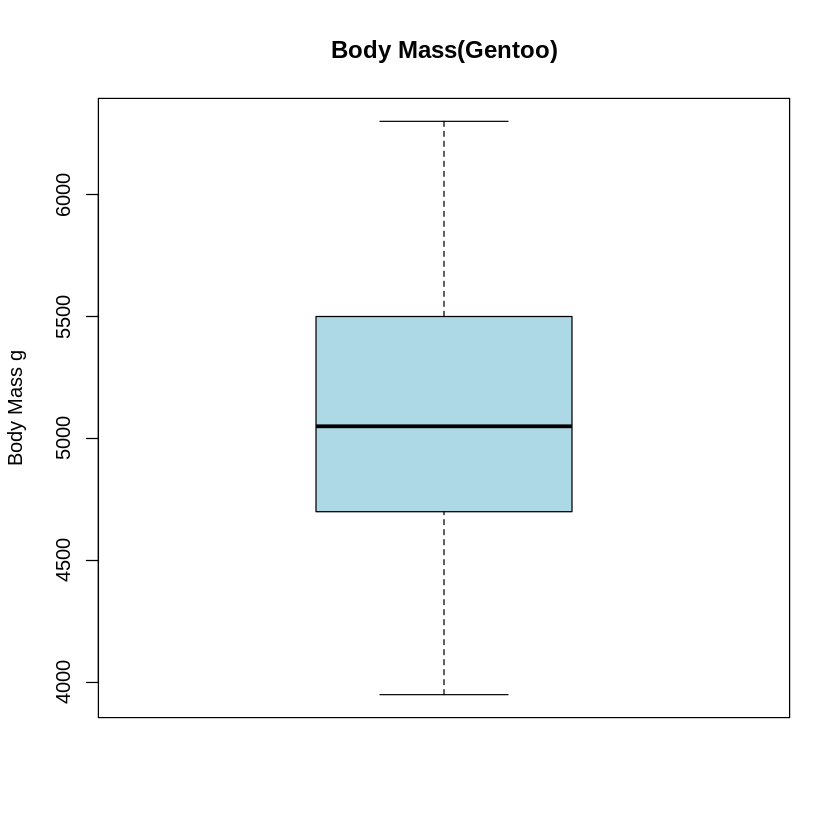

In [33]:

# Boxplot - Body Mass for Gentoo species
boxplot(x = data_new$bodymass[data_new$species == "Gentoo"],
        main = "Body Mass(Gentoo)",
        ylab = "Body Mass g",
        col = "lightblue")


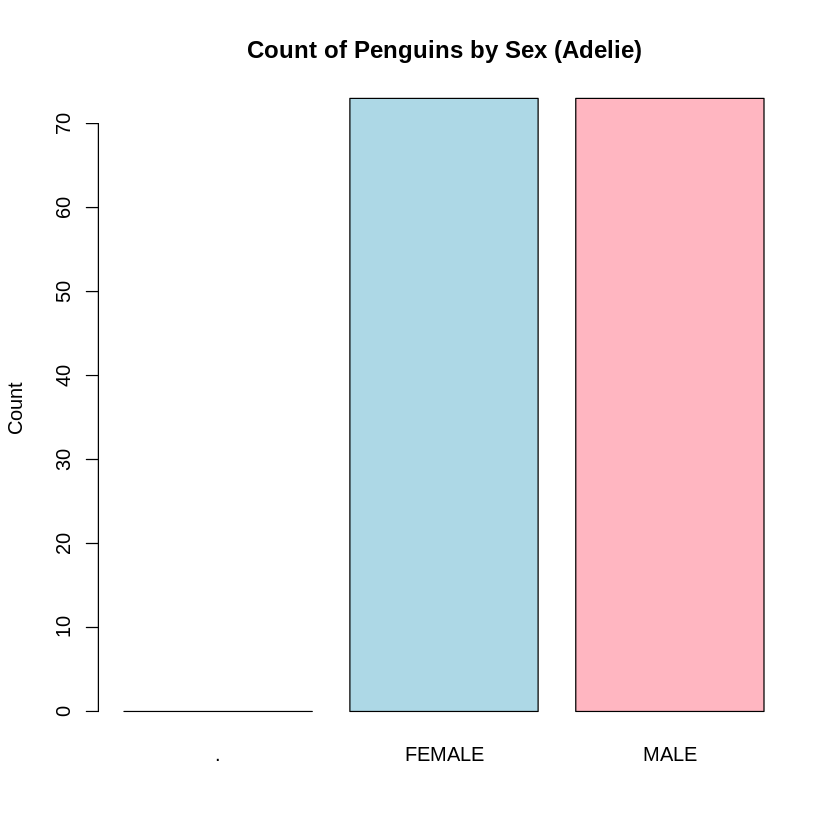

In [34]:
# Barchart - Sex - Adelie species
barplot(table(x = data_new$sex[data_new$species == "Adelie"]),
        main = "Count of Penguins by Sex (Adelie)",
        col = c("lightpink", "lightblue"),
        ylab = "Count")

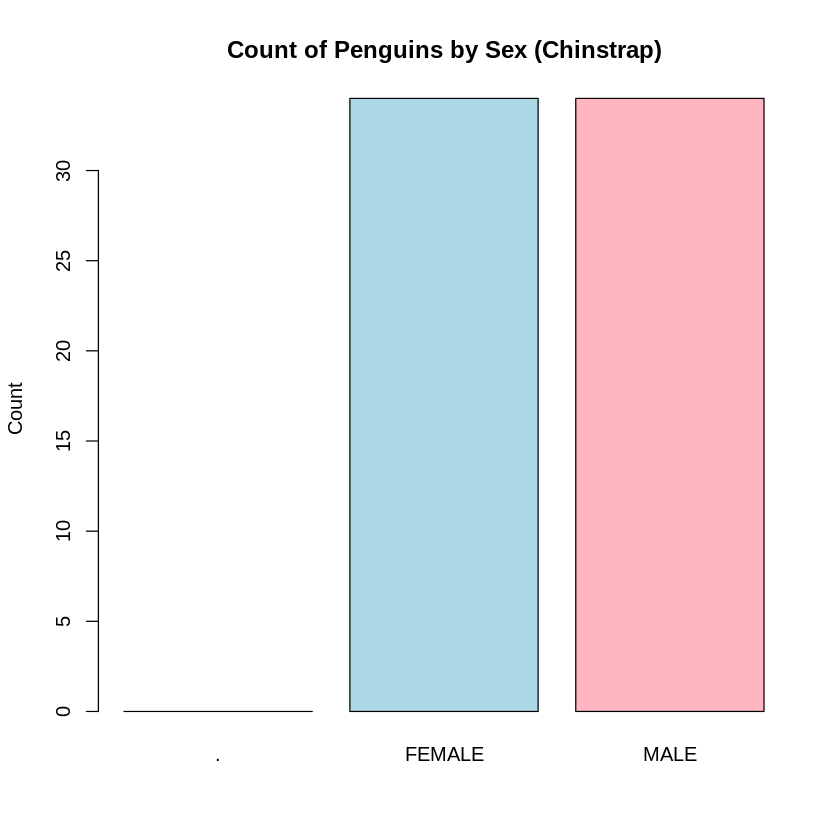

In [35]:
# Barchart - Sex - Chinstrap species
barplot(table(x = data_new$sex[data_new$species == "Chinstrap"]),
        main = "Count of Penguins by Sex (Chinstrap)",
        col = c("lightpink", "lightblue"),
        ylab = "Count")

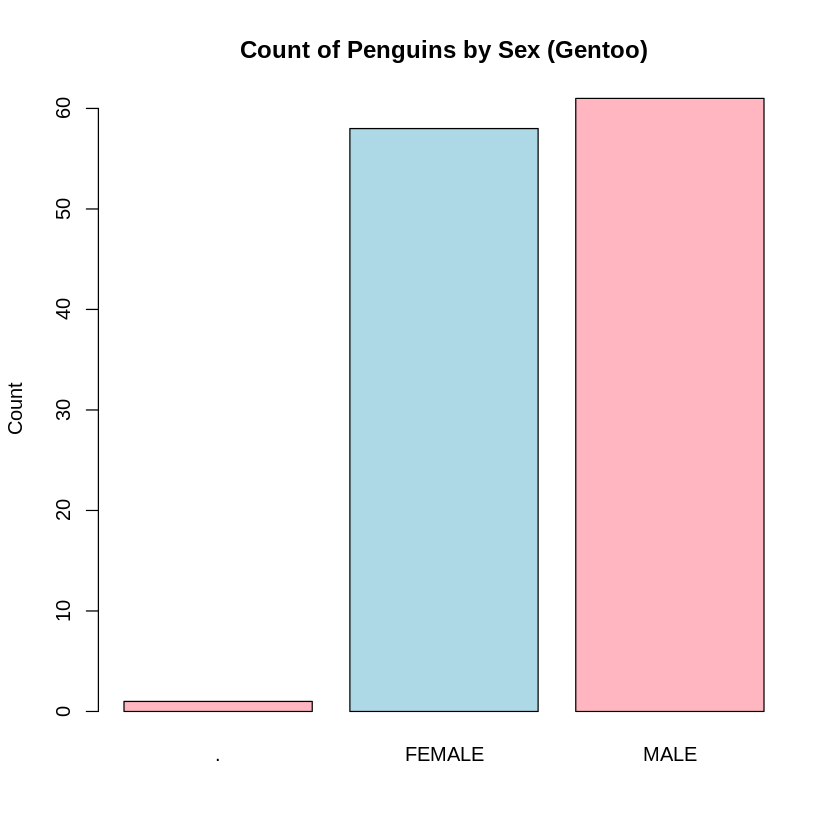

In [36]:
# Barchart - Sex - Gentoo species
barplot(table(x = data_new$sex[data_new$species == "Gentoo"]),
        main = "Count of Penguins by Sex (Gentoo)",
        col = c("lightpink", "lightblue"),
        ylab = "Count")

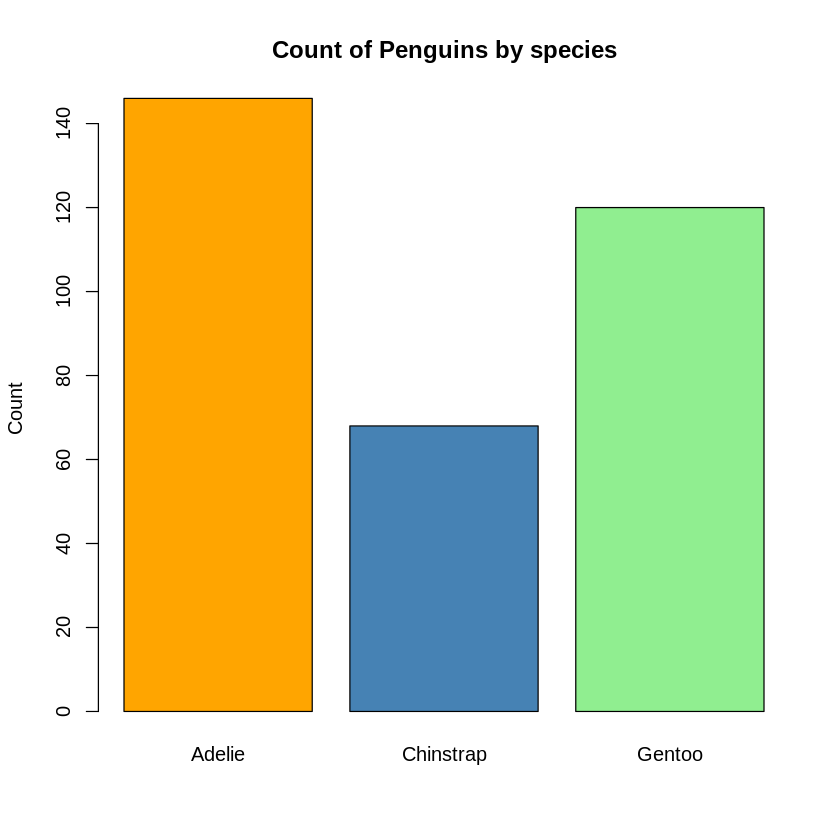

In [40]:
# Barchart - Species
barplot(table(data_new$species),
        main = "Count of Penguins by species",
        col = c("orange", "steelblue", "lightgreen"),
        ylab = "Count")

In [43]:
# Compute the Kurtosis for each numberic variable

# install the package named moments form the CRAN repository
install.packages("moments", repos = "https://cloud.r-project.org")

# Loads the moments pakage into your R session
library(moments)

# Select all numeric columns in the dataset and calculate the kurtosis for each one
sapply(data_new[, sapply(data_new, is.numeric)], kurtosis)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



culmenlength   culmendepth flipperlength      bodymass 
     2.118009      2.102349      2.025592      2.253739

In [ ]:
# create a frequenct table for each species and the proportion of each

cat("\n=== frequency table Species ===\n")
table(data_new$species)
prop.table(table(data_new$species))

cat("\n=== frequency table Island ===\n")
table(data_new$island)
prop.table(table(data_new$island))

cat("\n=== frequency table Sex ===\n")
table(data_new$sex)
prop.table(table(data_new$sex))


=== frequency table Species ===



   Adelie Chinstrap    Gentoo 
      146        68       120 


   Adelie Chinstrap    Gentoo 
0.4371257 0.2035928 0.3592814 


=== frequency table Island ===



   Biscoe     Dream Torgersen 
      164       123        47 


   Biscoe     Dream Torgersen 
0.4910180 0.3682635 0.1407186 


=== frequency table Sex ===



     . FEMALE   MALE 
     1    165    168 


          .      FEMALE        MALE 
0.002994012 0.494011976 0.502994012 

In [44]:
# notice in the previous output that there is an error for variable sex '.' recorded

data_new$sex[data_new$sex == "."] <- NA
data_new$sex <- factor(data_new$sex)  # re-factor to drop unused levels
unique(data_new$sex)
levels(data_new$sex)

data_new$sex <- droplevels(data_new$sex)
levels(data_new$sex)


[1] MALE   FEMALE <NA>  
Levels: FEMALE MALE

[1] "FEMALE" "MALE"

[1] "FEMALE" "MALE"

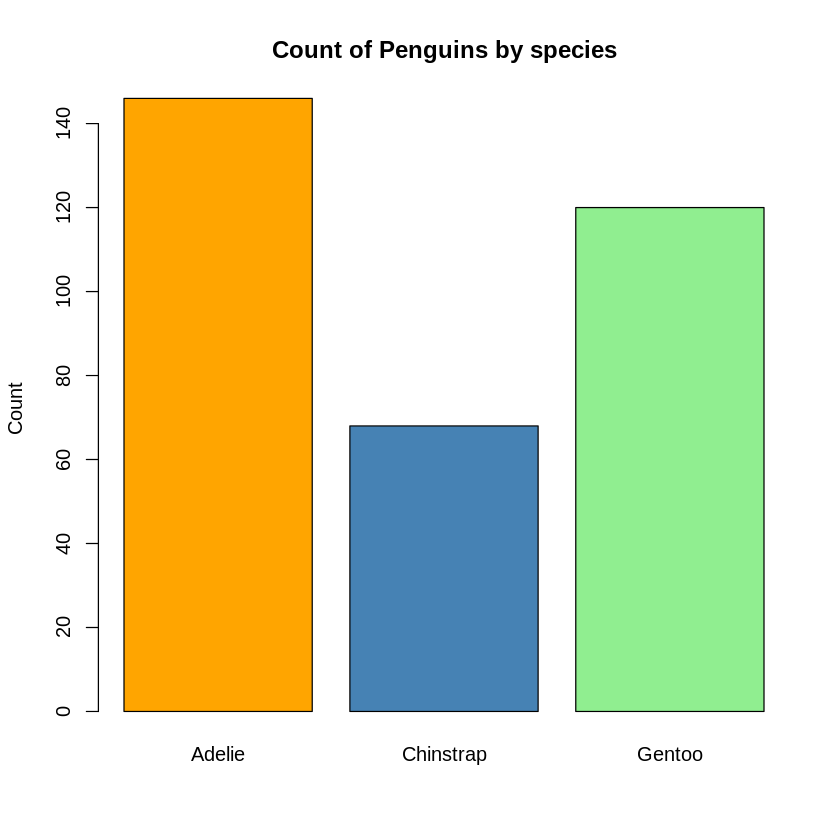

In [45]:

# Barchart - Species
barplot(table(data_new$species),
        main = "Count of Penguins by species",
        col = c("orange", "steelblue", "lightgreen"),
        ylab = "Count")


# **BIVARIATE ANALYSIS**

**Scatter plots - You don't need to complete all three steps below for scatter plot - choose one approach (1, 2, or 3)**

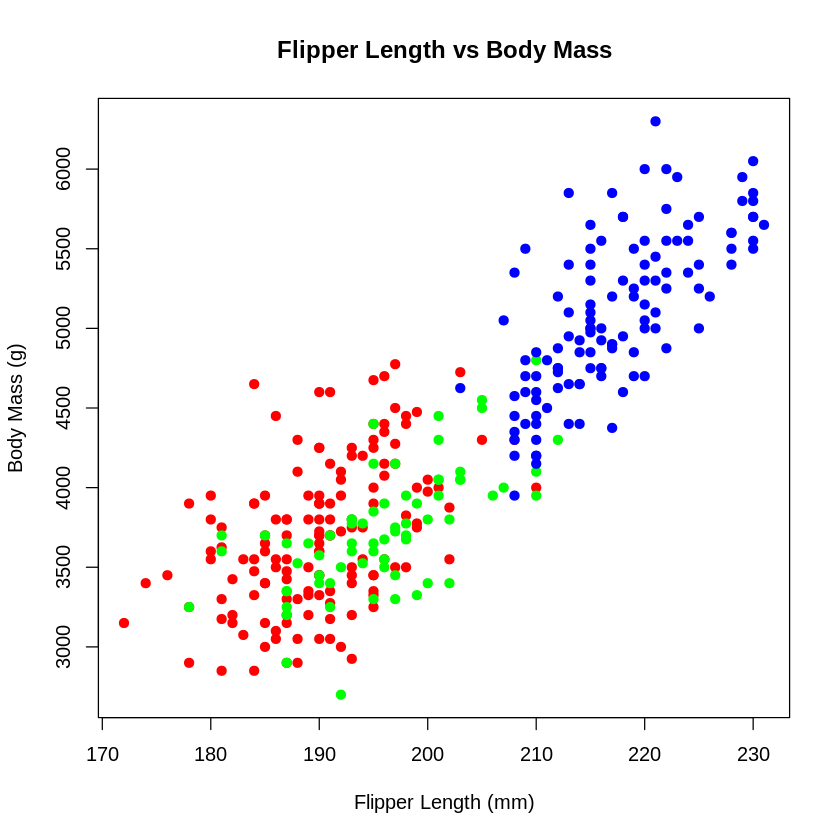

In [ ]:
# Scatter plots for numeric variables (approach 1)

# Assign colors to species
species_colors <- c("Adelie" = "red", "Chinstrap" = "green", "Gentoo" = "blue")

#Scatter plot of flipper length vs body mass
plot(data_new$flipperlength, data_new$bodymass,
     main = "Flipper Length vs Body Mass",
     xlab = "Flipper Length (mm)",
     ylab = "Body Mass (g)",
     pch = 19, col = species_colors[data_new$species])

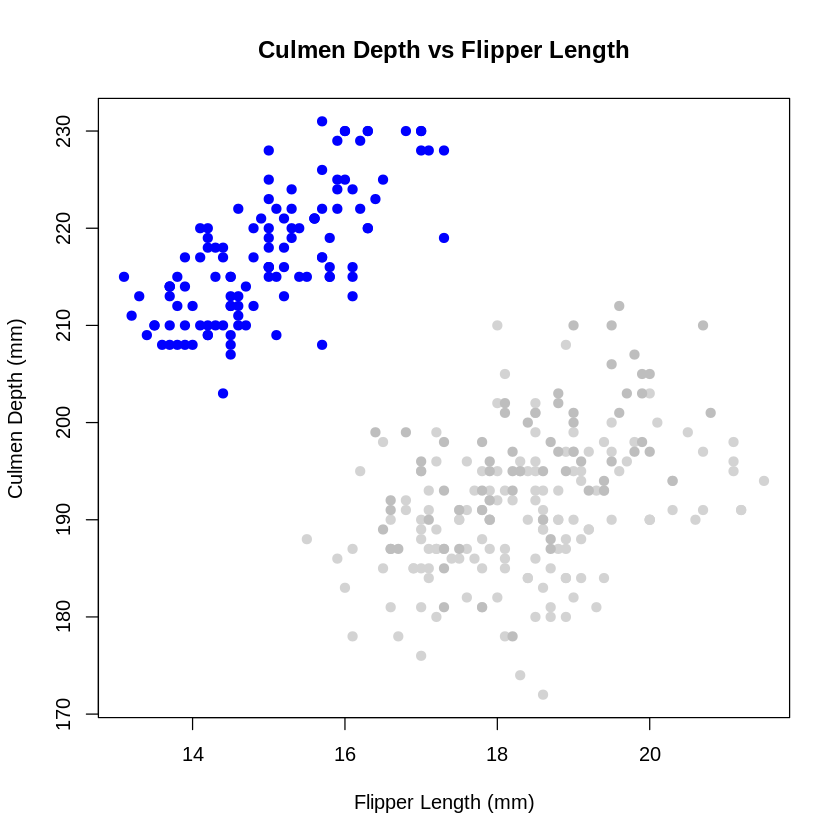

In [ ]:
# Scatter plots for numeric variables (approach 1)

# Assign colors to species
species_colors <- c("Adelie" = "lightgray", "Chinstrap" = "gray", "Gentoo" = "blue")

#Scatter plot of culmen depth vs flipper length
plot(data_new$culmendepth, data_new$flipperlength,
     main = "Culmen Depth vs Flipper Length",
     xlab = "Flipper Length (mm)",
     ylab = "Culmen Depth (mm)",
     pch = 19, col = species_colors[data_new$species])

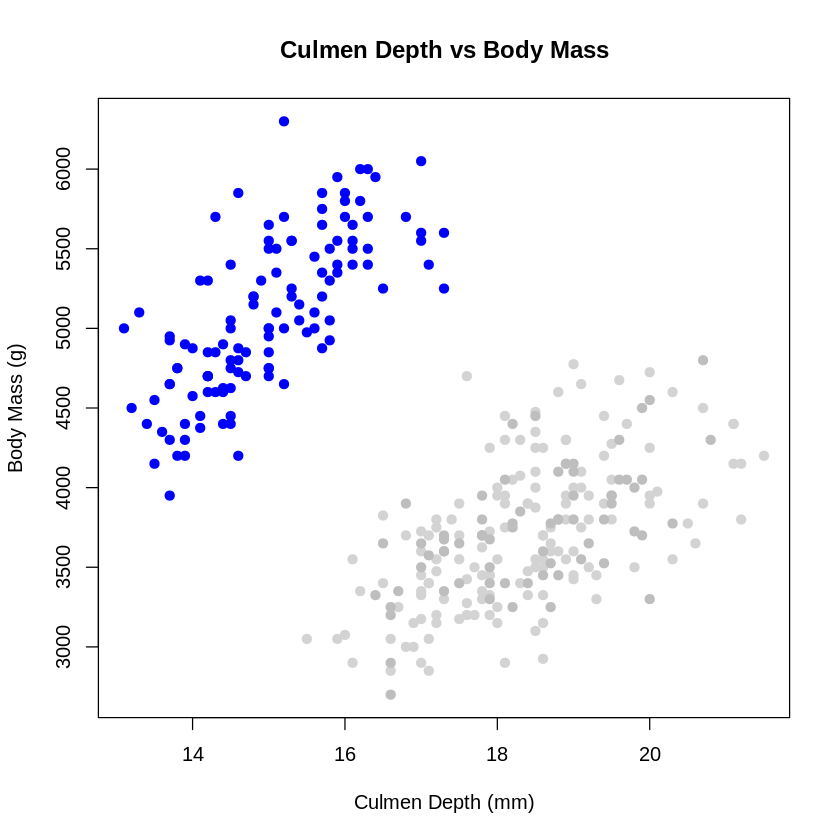

In [48]:
# Scatter plots for numeric variables (approach 1)

# Assign colors to species
species_colors <- c("Adelie" = "lightgray", "Chinstrap" = "gray", "Gentoo" = "blue")

#Scatter plot of culmen depth vs body mass
plot(data_new$culmendepth, data_new$bodymass,
     main = "Culmen Depth vs Body Mass",
     xlab = "Culmen Depth (mm)",
     ylab = "Body Mass (g)",
     pch = 19, col = species_colors[data_new$species])

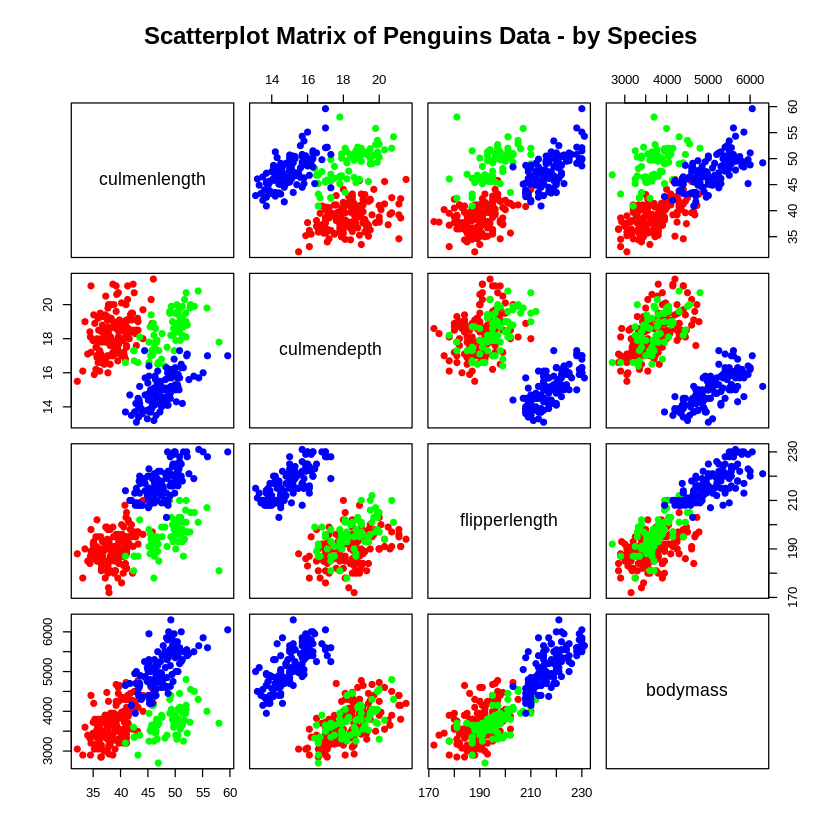

In [51]:
# Scatter plots for numeric variables (approach 3)

# Assign colors to species
species_colors <- c("Adelie" = "red", "Chinstrap" = "green", "Gentoo" = "blue")

numeric_vars <- names(data_new)[sapply(data_new, is.numeric)]

# Create scatterplot matrix (pairs plot)
pairs(data_new[, numeric_vars],
      main = "Scatterplot Matrix of Penguins Data - by Species",
      pch = 19,
      col = species_colors[data_new$species])


In [52]:
# Creates a data frame of just numeric columns
numeric_data <- data_new[, sapply(data_new, is.numeric)]

# computes the correlation matrix. 'use = "pairwise.complete.obs"'ignores missing vlaues when calculating correlation
cor_mat <- cor(numeric_data, use = "pairwise.complete.obs")

# Display the correlation matrix
print(cor_mat)

              culmenlength culmendepth flipperlength   bodymass
culmenlength     1.0000000  -0.2286400     0.6521257  0.5890662
culmendepth     -0.2286400   1.0000000    -0.5787295 -0.4729870
flipperlength    0.6521257  -0.5787295     1.0000000  0.8732110
bodymass         0.5890662  -0.4729870     0.8732110  1.0000000


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



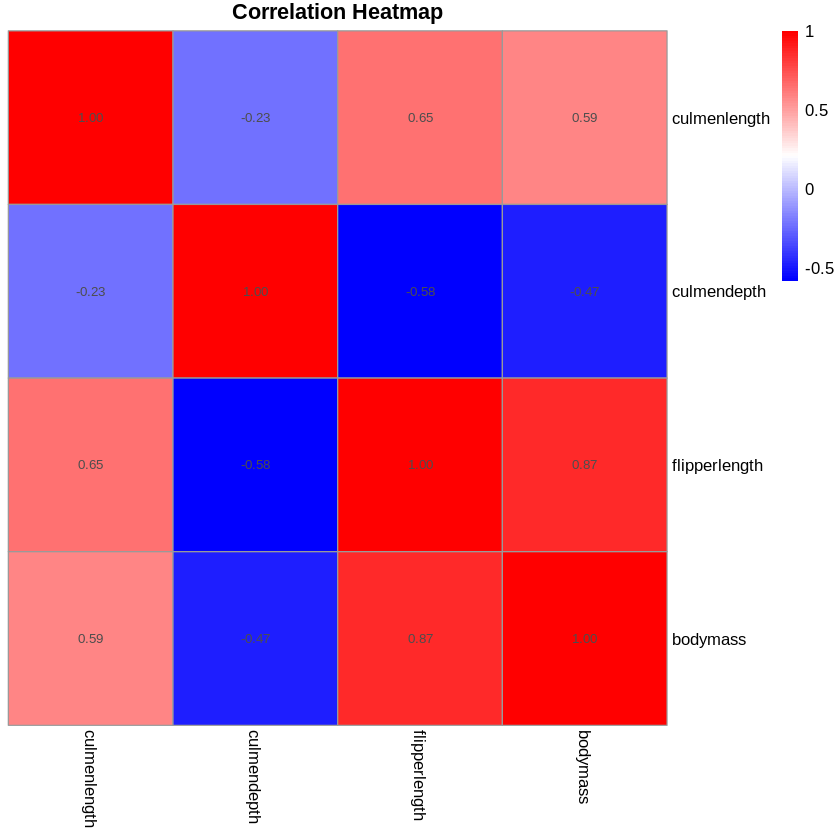

In [53]:
# Install and Load the required package
install.packages("pheatmap")
# Used for creating heatmaps
library(pheatmap)

# Create a correlation heatmap, diable clustering lines to keep the original order of attributes
pheatmap(cor_mat,
        cluster_rows = FALSE,
         cluster_cols = FALSE,
         display_numbers = TRUE, number_format = "%.2f",
         color = colorRampPalette(c("blue","white","red"))(100),
         clustering_method = "complete", legend = TRUE,
         main = "Correlation Heatmap")

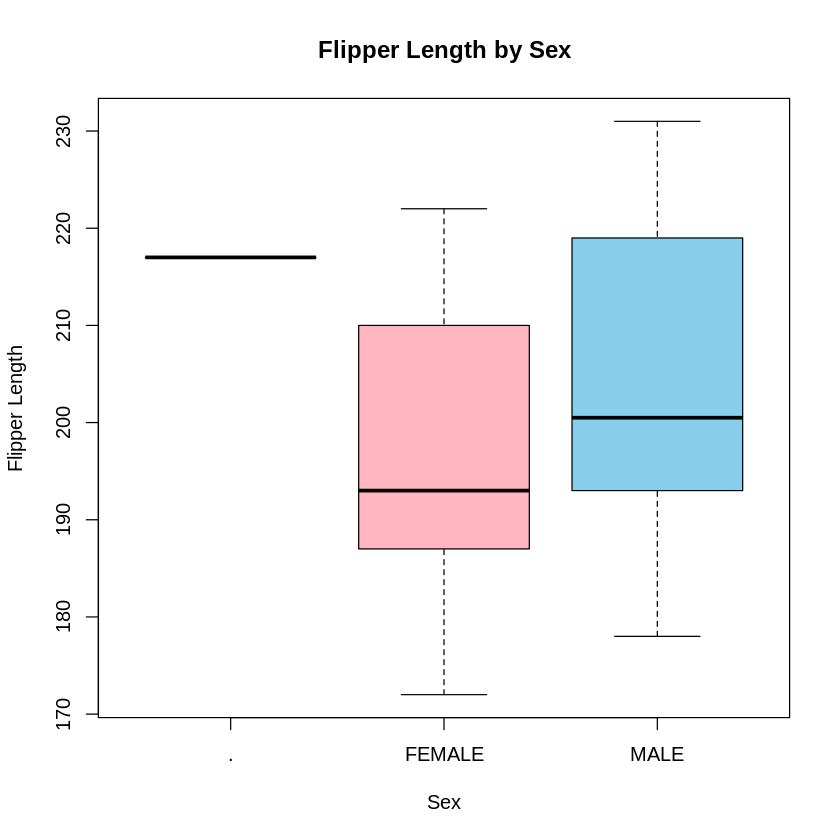

In [ ]:
# Boxplots - BIVARIATE Analysis 1 categorical variable + 1 numerical variable
#Flipper length x Sex
boxplot(flipperlength ~ sex, data_new,
        main = "Flipper Length by Sex",
        xlab = "Sex", ylab = "Flipper Length",
        col = c("skyblue", "lightpink"))

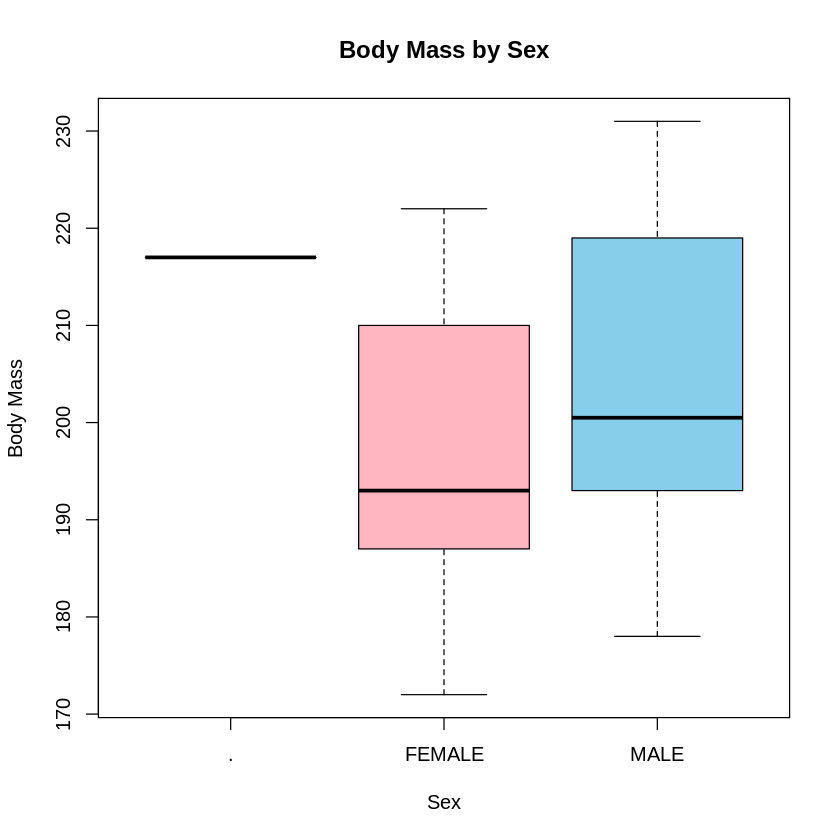

In [ ]:
# Boxplots - BIVARIATE Analysis 1 categorical variable + 1 numerical variable
#Body mass x Sex
boxplot(flipperlength ~ sex, data_new,
        main = "Body Mass by Sex",
        xlab = "Sex", ylab = "Body Mass",
        col = c("skyblue", "lightpink"))

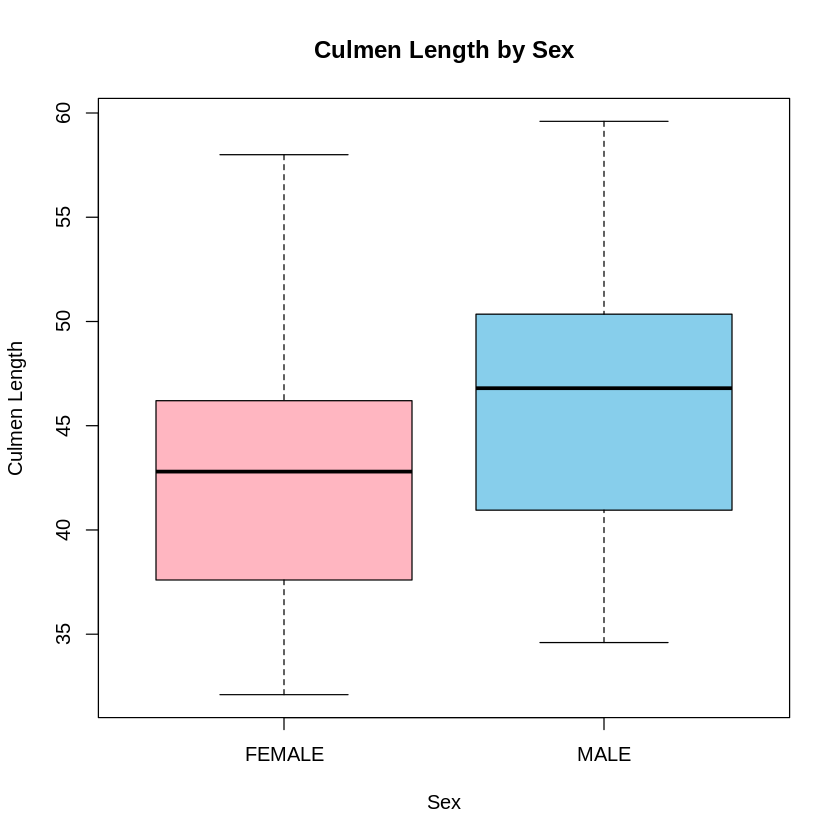

In [56]:
# Boxplots - BIVARIATE Analysis 1 categorical variable + 1 numerical variable
#Culmen Length x Sex
boxplot(culmenlength ~ sex, data_new,
        main = "Culmen Length by Sex",
        xlab = "Sex", ylab = "Culmen Length",
        col = c("lightpink", "skyblue"))

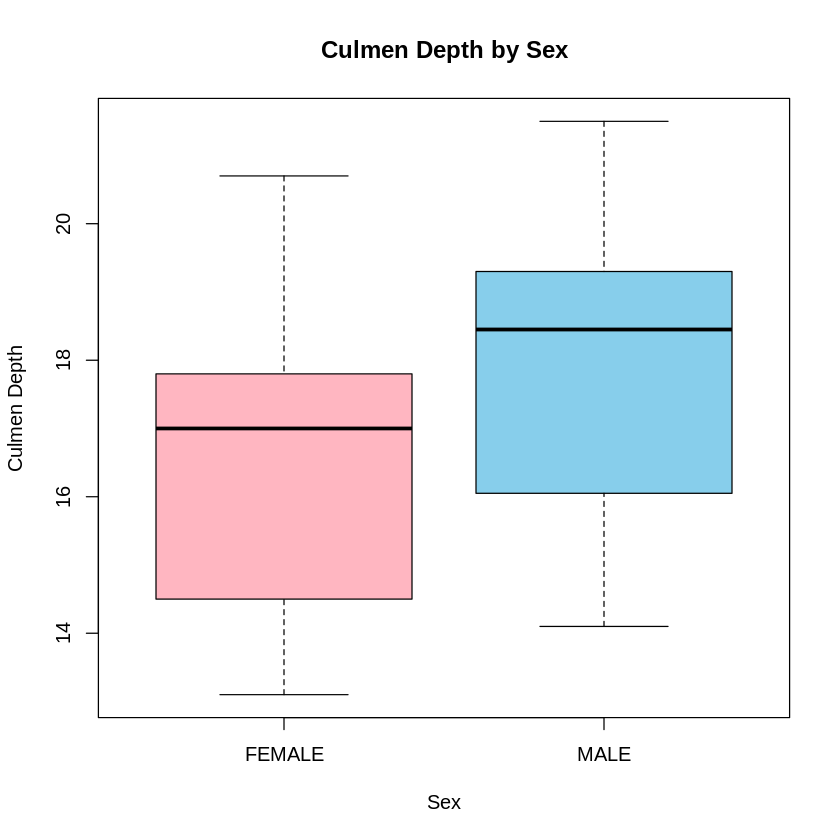

In [57]:
# Boxplots - BIVARIATE Analysis 1 categorical variable + 1 numerical variable
#Culmen Depth x Sex
boxplot(culmendepth ~ sex, data_new,
        main = "Culmen Depth by Sex",
        xlab = "Sex", ylab = "Culmen Depth",
        col = c("lightpink", "skyblue"))